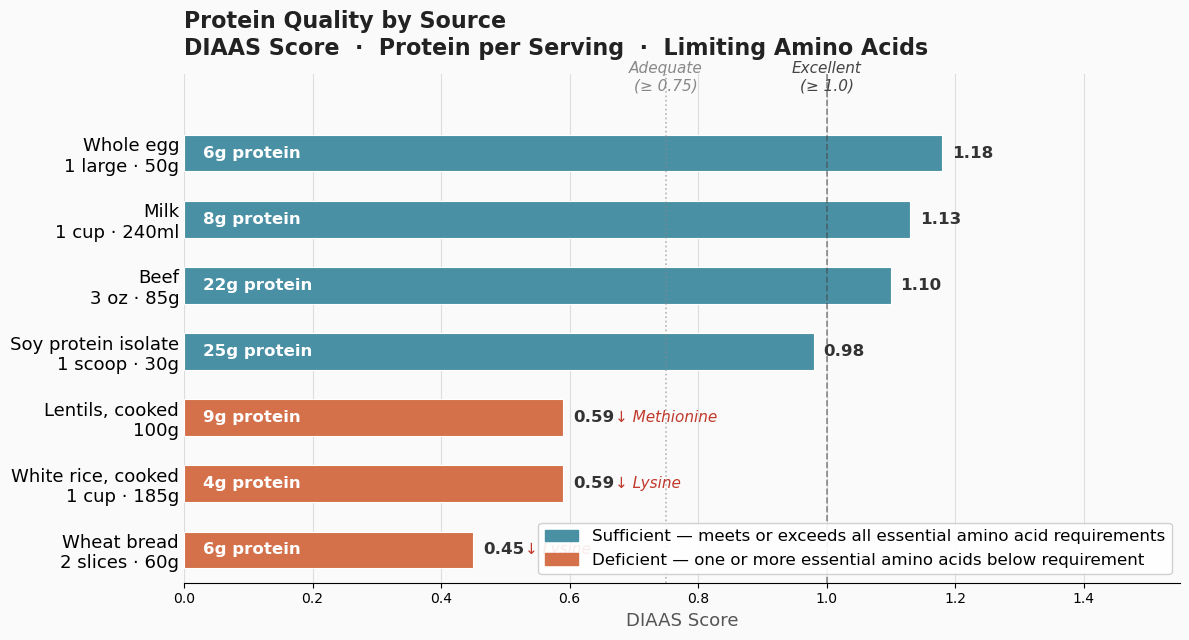

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# All five columns from the table, sorted ascending (worst at bottom)
sources = [
    'Wheat bread\n2 slices · 60g',
    'White rice, cooked\n1 cup · 185g',
    'Lentils, cooked\n100g',
    'Soy protein isolate\n1 scoop · 30g',
    'Beef\n3 oz · 85g',
    'Milk\n1 cup · 240ml',
    'Whole egg\n1 large · 50g',
]
diaas   = [0.45, 0.59, 0.59, 0.98, 1.10, 1.13, 1.18]
protein = [6,    4,    9,    25,   22,   8,    6   ]
limiting = ['Lysine', 'Lysine', 'Methionine', None, None, None, None]

SUFFICIENT_COLOR = '#4A90A4'   # teal-blue
DEFICIENT_COLOR  = '#D4704A'   # warm orange

colors = [DEFICIENT_COLOR if lim else SUFFICIENT_COLOR for lim in limiting]

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

y_pos = np.arange(len(sources))

ax.barh(y_pos, diaas, color=colors, height=0.55,
        edgecolor='white', linewidth=0.8, zorder=3)

# Subtle grid
ax.xaxis.grid(True, color='#dddddd', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Reference lines
ax.axvline(x=1.0,  color='#444444', linestyle='--', linewidth=1.2, alpha=0.6, zorder=4)
ax.axvline(x=0.75, color='#888888', linestyle=':',  linewidth=1.2, alpha=0.6, zorder=4)

# Annotations on each bar
for i, (d, p, lim) in enumerate(zip(diaas, protein, limiting)):
    # Protein grams inside the bar
    ax.text(0.03, i, f'{p}g protein',
            va='center', ha='left', fontsize=12,
            color='white', fontweight='bold', zorder=5)
    # DIAAS score just right of bar end
    ax.text(d + 0.015, i, f'{d:.2f}',
            va='center', ha='left', fontsize=12,
            color='#333333', fontweight='bold', zorder=5)
    # Limiting amino acid for deficient proteins
    if lim:
        ax.text(d + 0.08, i, f'↓ {lim}',
                va='center', ha='left', fontsize=11,
                color='#c0392b', style='italic', zorder=5)

# Axes
ax.set_yticks(y_pos)
ax.set_yticklabels(sources, fontsize=13)
ax.set_xlabel('DIAAS Score', fontsize=13, color='#555555')
ax.set_xlim(0, 1.55)
ax.set_ylim(-0.5, len(sources) + 0.2)

# Reference line labels at the top
ax.text(1.0,  len(sources) - 0.1, 'Excellent\n(≥ 1.0)',  fontsize=11,
        color='#444444', ha='center', va='bottom', style='italic')
ax.text(0.75, len(sources) - 0.1, 'Adequate\n(≥ 0.75)', fontsize=11,
        color='#888888', ha='center', va='bottom', style='italic')

# Title
ax.set_title(
    'Protein Quality by Source\n'
    'DIAAS Score  ·  Protein per Serving  ·  Limiting Amino Acids',
    fontsize=16, fontweight='bold', color='#222222', pad=14, loc='left'
)

# Legend
ax.legend(
    handles=[
        mpatches.Patch(color=SUFFICIENT_COLOR,
                       label='Sufficient — meets or exceeds all essential amino acid requirements'),
        mpatches.Patch(color=DEFICIENT_COLOR,
                       label='Deficient — one or more essential amino acids below requirement'),
    ],
    loc='lower right', fontsize=12, framealpha=0.9, edgecolor='#cccccc'
)

# Clean up spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig('protein_quality_chart.png', dpi=300,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
